<a href="https://colab.research.google.com/github/Raksh1707/Naturalproject/blob/main/nlp7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
import string
from collections import Counter

from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

# Download NLTK resources
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [2]:
reviews = [
    "The room was clean and spacious. Staff were very friendly.",
    "Excellent food and wonderful service.",
    "The bathroom was dirty and the room smelled bad.",
    "Amazing stay. Comfortable bed and clean room.",
    "Poor customer service and slow check-in process.",
    "The swimming pool was clean and well maintained.",
    "Food quality was average but the room was comfortable.",
    "Very noisy room during the night.",
    "Staff were polite and helpful throughout our stay.",
    "The WiFi connection was very slow.",
    "Breakfast was delicious and fresh.",
    "The room was not cleaned properly.",
    "Excellent location and beautiful hotel.",
    "Air conditioning was not working.",
    "The staff responded quickly to our requests.",
    "Parking facility was convenient.",
    "The restaurant service was too slow.",
    "Loved the clean rooms and peaceful environment.",
    "The hotel needs better maintenance.",
    "Very satisfied with the hospitality.",
    "The room was small but neat.",
    "Housekeeping service was excellent.",
    "Food was cold and tasteless.",
    "The reception staff were very rude.",
    "Fantastic experience. Highly recommended.",
    "Bathroom cleanliness should be improved.",
    "Comfortable stay with excellent amenities.",
    "The bed sheets were dirty.",
    "Quick check-in and friendly staff.",
    "Overall a wonderful hotel experience."
]

df = pd.DataFrame({"Review": reviews})

print("First 5 Reviews")
print(df.head())

First 5 Reviews
                                              Review
0  The room was clean and spacious. Staff were ve...
1              Excellent food and wonderful service.
2   The bathroom was dirty and the room smelled bad.
3      Amazing stay. Comfortable bed and clean room.
4   Poor customer service and slow check-in process.


In [3]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    words = text.split()

    # Remove stop words
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Clean_Review"] = df["Review"].apply(clean_text)

print("\nClean Reviews")
print(df[["Review","Clean_Review"]].head())


Clean Reviews
                                              Review  \
0  The room was clean and spacious. Staff were ve...   
1              Excellent food and wonderful service.   
2   The bathroom was dirty and the room smelled bad.   
3      Amazing stay. Comfortable bed and clean room.   
4   Poor customer service and slow check-in process.   

                                 Clean_Review  
0          room clean spacious staff friendly  
1            excellent food wonderful service  
2             bathroom dirty room smelled bad  
3     amazing stay comfortable bed clean room  
4  poor customer service slow checkin process  


In [4]:
sia = SentimentIntensityAnalyzer()

def sentiment(review):

    score = sia.polarity_scores(review)["compound"]

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Review"].apply(sentiment)

print("\nSentiment Analysis")
print(df[["Review","Sentiment"]])


Sentiment Analysis
                                               Review Sentiment
0   The room was clean and spacious. Staff were ve...  Positive
1               Excellent food and wonderful service.  Positive
2    The bathroom was dirty and the room smelled bad.  Negative
3       Amazing stay. Comfortable bed and clean room.  Positive
4    Poor customer service and slow check-in process.  Negative
5    The swimming pool was clean and well maintained.  Positive
6   Food quality was average but the room was comf...  Positive
7                   Very noisy room during the night.  Negative
8   Staff were polite and helpful throughout our s...  Positive
9                  The WiFi connection was very slow.   Neutral
10                 Breakfast was delicious and fresh.  Positive
11                 The room was not cleaned properly.   Neutral
12            Excellent location and beautiful hotel.  Positive
13                  Air conditioning was not working.   Neutral
14       The staff r

In [5]:
issue_keywords = [
    "dirty",
    "slow",
    "bad",
    "noise",
    "noisy",
    "wifi",
    "food",
    "bathroom",
    "maintenance",
    "parking",
    "staff",
    "service",
    "clean",
    "room"
]

all_words = " ".join(df["Clean_Review"]).split()

issues = [word for word in all_words if word in issue_keywords]

issue_count = Counter(issues)

print("\nService Related Issues")
for issue, count in issue_count.items():
    print(issue, ":", count)


Service Related Issues
room : 7
clean : 4
staff : 5
food : 3
service : 4
bathroom : 2
dirty : 2
bad : 1
slow : 3
noisy : 1
wifi : 1
parking : 1
maintenance : 1


In [6]:
print("\nCustomer Satisfaction Report")

print(df["Sentiment"].value_counts())


Customer Satisfaction Report
Sentiment
Positive    18
Neutral      7
Negative     5
Name: count, dtype: int64


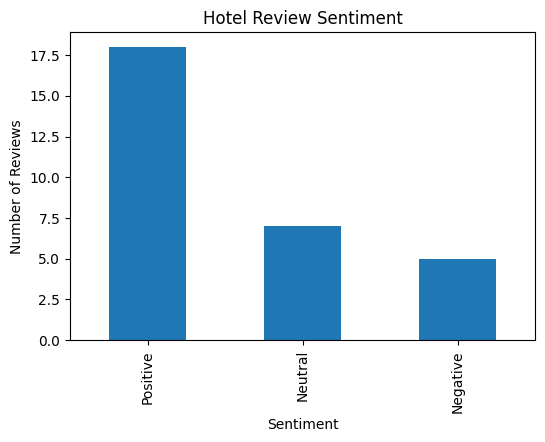

In [7]:
plt.figure(figsize=(6,4))

df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Hotel Review Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

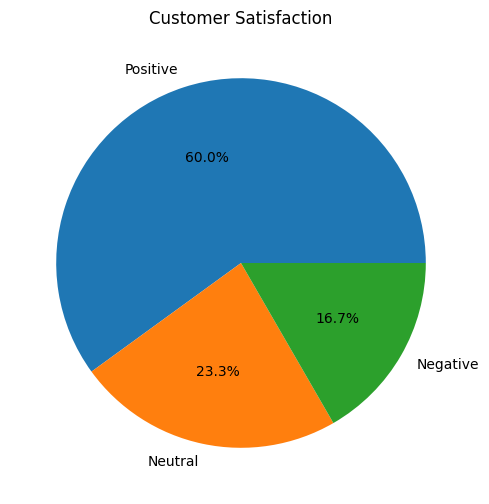

In [8]:
plt.figure(figsize=(6,6))

df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Customer Satisfaction")

plt.show()

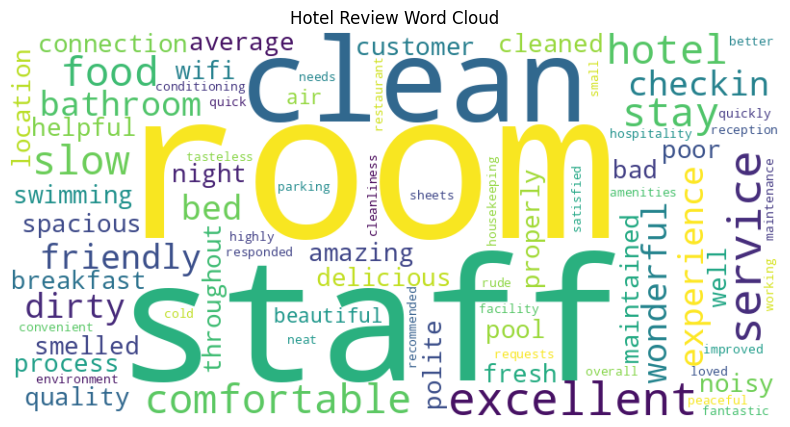

In [9]:
text = " ".join(df["Clean_Review"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Hotel Review Word Cloud")

plt.show()


In [10]:
df.to_csv("Hotel_Review_Analysis_Output.csv", index=False)

print("\nAnalysis Completed Successfully!")
print("Output saved as Hotel_Review_Analysis_Output.csv")


Analysis Completed Successfully!
Output saved as Hotel_Review_Analysis_Output.csv
